#### Partial Dependence

In [26]:
# ============================================================
# PARTIAL DEPENDENCE / PREDICTED RELATIONSHIP PLOTS FOR SEM
# Based on:
#   1) sem_2factor_key_structural_paths.csv
#   2) sem_2factor_parameter_estimates.csv
#   3) all_state_local_fund_latent_var_4_v2.csv
#
# Outputs:
#   - SEM-implied predicted relationship plots for latent constructs
#   - Indicator-level partial dependence plots (OLS-based)
#   - Significant control-variable plots
#   - Structural coefficient plots with significance stars
# ============================================================

# -----------------------------
# 0. Install packages if needed
# -----------------------------
# !pip install pandas numpy matplotlib statsmodels scikit-learn

import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
from statsmodels.nonparametric.smoothers_lowess import lowess

# -----------------------------
# 1. File paths
# -----------------------------
PATH_STRUCT = "baseline_sem_4/sem_2factor_key_structural_paths.csv"
PATH_PARAM  = "baseline_sem_4/sem_2factor_parameter_estimates.csv"
PATH_RAW    = "all_state_local_fund_latent_var_4_v2.csv"

OUTDIR = "sem_partial_dependence_outputs"
os.makedirs(OUTDIR, exist_ok=True)

# -----------------------------
# 2. Load data
# -----------------------------
struct_df = pd.read_csv(PATH_STRUCT)
param_df  = pd.read_csv(PATH_PARAM)
raw_df    = pd.read_csv(PATH_RAW)

print("Structural paths:", struct_df.shape)
print("Parameter estimates:", param_df.shape)
print("Raw data:", raw_df.shape)

# -----------------------------
# 3. Prepare SEM input variables
#    Match your SEM preprocessing
# -----------------------------
df = raw_df.copy()

# state-level indicator
df["state_level"] = df["Grantee"].astype(str).str.fullmatch(r"[A-Z]{2}").astype(int)

# reverse-code workload burden indicators
eps = 1e-6
df["programs_per_staff"] = df["Num_Program"] / (df["avg_employment"] + eps)
df["disasters_per_staff"] = df["Num_Disaster"] / (df["avg_employment"] + eps)

df["rev_programs_per_staff"] = -df["programs_per_staff"]
df["rev_disasters_per_staff"] = -df["disasters_per_staff"]

# reverse-code recovery timeliness indicators
df["rev_Duration_of_completion"] = -df["Duration_of_completion"]
df["rev_Average_Duration_Program_Completion"] = -df["Average_Duration_Program_Completion"]
# df["rev_Quarter_variance"] = -df["Quarter_by_quarter_variance_expended"]

# variables used here
continuous_vars = [
    "avg_employment",
    "avg_payroll",
    "rev_programs_per_staff",
    "rev_disasters_per_staff",
    "Ratio_disbursed_to_obligated",
    "Ratio_expended_to_disbursed",
    "Ratio_obligated_funds_fully_expended",
    "Ratio_Program_Completed",
    # "Timeliness",
    "rev_Duration_of_completion",
    "rev_Average_Duration_Program_Completion",
    # "rev_Quarter_variance",
    "E_TOTPOP",
    "SPL_THEME1",
    "SPL_THEME2",
    "SPL_THEME3",
    "SPL_THEME4",
]

# drop rows with missing values in required columns
required_cols = ["Grantee", "state_level"] + continuous_vars
df = df[required_cols].dropna().copy()

# standardize continuous variables
scaler = StandardScaler()
zvals = scaler.fit_transform(df[continuous_vars])
zcols = [f"z_{c}" for c in continuous_vars]
zdf = pd.DataFrame(zvals, columns=zcols, index=df.index)

df = pd.concat([df, zdf], axis=1)

# -----------------------------
# 4. Build proxy latent scores
#    These are not semopy factor scores.
#    They are practical composite proxies for plotting.
# -----------------------------

df["AdminResources_proxy"] = df[[
    "z_avg_employment",
    "z_avg_payroll"
]].mean(axis=1)

df["AdminBurdenCapacity_proxy"] = df[[
    "z_rev_programs_per_staff",
    "z_rev_disasters_per_staff"
]].mean(axis=1)

df["RecoveryPerformance_proxy"] = df[[
    "z_Ratio_disbursed_to_obligated",
    "z_Ratio_expended_to_disbursed",
    "z_Ratio_obligated_funds_fully_expended",
    "z_Ratio_Program_Completed"
]].mean(axis=1)

df["RecoveryTimeliness_proxy"] = df[[
    "z_rev_Duration_of_completion",
    "z_rev_Average_Duration_Program_Completion"
]].mean(axis=1)

# -----------------------------
# 5. Helper functions
# -----------------------------
def p_to_stars(p):
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    elif p < 0.10:
        return "†"
    return ""

def get_sem_path(struct_paths, outcome, predictor):
    row = struct_paths[
        (struct_paths["lval"] == outcome) &
        (struct_paths["op"] == "~") &
        (struct_paths["rval"] == predictor)
    ]
    if row.empty:
        return None
    return row.iloc[0]

def safe_filename(x):
    return (
        str(x)
        .replace(" ", "_")
        .replace("/", "_")
        .replace("~", "to")
        .replace("(", "")
        .replace(")", "")
        .replace("-", "_")
    )

def plot_sem_implied_continuous(
    df,
    x_proxy_col,
    y_proxy_col,
    sem_outcome_name,
    sem_predictor_name,
    struct_paths,
    outfile,
    show_lowess=True,
    x_label=None,
    y_label=None,
    title=None
):
    """
    Plot SEM-implied standardized linear relationship:
        y = beta * x
    with observed proxy score scatter for context.
    """
    info = get_sem_path(struct_paths, sem_outcome_name, sem_predictor_name)
    if info is None:
        print(f"Skip: no SEM path found for {sem_predictor_name} -> {sem_outcome_name}")
        return

    beta = float(info["Est. Std"])
    se = float(info["Std. Err"])
    p  = float(info["p-value"])
    stars = p_to_stars(p)

    x_obs = df[x_proxy_col].values
    y_obs = df[y_proxy_col].values

    x_line = np.linspace(np.nanpercentile(x_obs, 1), np.nanpercentile(x_obs, 99), 250)
    y_line = beta * x_line

    # approximate CI around slope line
    y_low = (beta - 1.96 * se) * x_line
    y_up  = (beta + 1.96 * se) * x_line

    plt.figure(figsize=(6.5, 4.8))
    plt.scatter(x_obs, y_obs, alpha=0.25, s=18)
    plt.plot(x_line, y_line, linewidth=2.2, label=f"SEM-implied slope: β = {beta:.3f}{stars}")
    plt.fill_between(x_line, y_low, y_up, alpha=0.18, label="Approx. 95% CI")

    if show_lowess:
        smoothed = lowess(y_obs, x_obs, frac=0.35, return_sorted=True)
        plt.plot(smoothed[:, 0], smoothed[:, 1], linestyle="--", linewidth=1.8, label="LOWESS (exploratory)")

    plt.axhline(0, linestyle="--", linewidth=0.8)
    plt.axvline(0, linestyle="--", linewidth=0.8)

    plt.xlabel(x_label if x_label else x_proxy_col)
    plt.ylabel(y_label if y_label else y_proxy_col)
    plt.title(title if title else f"{sem_predictor_name} → {sem_outcome_name}")
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.savefig(outfile, dpi=300, bbox_inches="tight")
    plt.close()

def fit_partial_dependence_ols(df, y_col, focal_x, all_x):
    """
    OLS-based partial dependence:
    Predict y while varying focal_x and holding all others at their means.
    """
    X = df[all_x].copy()
    X = sm.add_constant(X, has_constant="add")
    y = df[y_col].copy()

    model = sm.OLS(y, X).fit()

    # build prediction grid
    x_min = np.nanpercentile(df[focal_x], 1)
    x_max = np.nanpercentile(df[focal_x], 99)
    x_grid = np.linspace(x_min, x_max, 200)

    pred_df = pd.DataFrame(index=range(len(x_grid)))
    for col in all_x:
        pred_df[col] = df[col].mean()
    pred_df[focal_x] = x_grid

    pred_X = sm.add_constant(pred_df, has_constant="add")
    pred_res = model.get_prediction(pred_X).summary_frame(alpha=0.05)

    result_df = pred_df.copy()
    result_df["pred_mean"] = pred_res["mean"].values
    result_df["pred_low"] = pred_res["mean_ci_lower"].values
    result_df["pred_up"] = pred_res["mean_ci_upper"].values

    return model, result_df

def plot_partial_dependence_ols(
    df,
    y_col,
    focal_x,
    all_x,
    outfile,
    x_label=None,
    y_label=None,
    title=None,
    add_lowess=True
):
    model, pred_df = fit_partial_dependence_ols(df, y_col, focal_x, all_x)

    coef = model.params[focal_x]
    pval = model.pvalues[focal_x]
    stars = p_to_stars(pval)

    x_obs = df[focal_x].values
    y_obs = df[y_col].values

    plt.figure(figsize=(6.5, 4.8))
    plt.scatter(x_obs, y_obs, alpha=0.22, s=18)
    plt.plot(pred_df[focal_x], pred_df["pred_mean"], linewidth=2.2,
             label=f"Partial dependence: β = {coef:.3f}{stars}")
    plt.fill_between(pred_df[focal_x], pred_df["pred_low"], pred_df["pred_up"], alpha=0.18)

    if add_lowess:
        smoothed = lowess(y_obs, x_obs, frac=0.35, return_sorted=True)
        plt.plot(smoothed[:, 0], smoothed[:, 1], linestyle="--", linewidth=1.8, label="LOWESS (exploratory)")

    plt.axhline(0, linestyle="--", linewidth=0.8)
    plt.axvline(0, linestyle="--", linewidth=0.8)
    plt.xlabel(x_label if x_label else focal_x)
    plt.ylabel(y_label if y_label else y_col)
    plt.title(title if title else f"{focal_x} → {y_col}")
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.savefig(outfile, dpi=300, bbox_inches="tight")
    plt.close()

    return model

def plot_binary_effect_sem(
    df,
    y_proxy_col,
    sem_outcome_name,
    sem_predictor_name,
    struct_paths,
    outfile,
    title=None,
    y_label=None
):
    """
    For binary state_level. Plot SEM-implied means at 0 vs 1.
    Since standardized SEM uses beta on latent outcome:
       predicted y(0)=0
       predicted y(1)=beta
    Also show observed proxy means for context.
    """
    info = get_sem_path(struct_paths, sem_outcome_name, sem_predictor_name)
    if info is None:
        print(f"Skip: no SEM path found for {sem_predictor_name} -> {sem_outcome_name}")
        return

    beta = float(info["Est. Std"])
    p = float(info["p-value"])
    stars = p_to_stars(p)

    observed = df.groupby("state_level")[y_proxy_col].mean()

    x = np.array([0, 1])
    y = np.array([0, beta])

    plt.figure(figsize=(5.8, 4.5))
    plt.plot(x, y, marker="o", linewidth=2.2, label=f"SEM-implied effect: β = {beta:.3f}{stars}")
    plt.scatter(observed.index.values, observed.values, s=80, label="Observed proxy means")

    plt.xticks([0, 1], ["Local", "State"])
    plt.ylabel(y_label if y_label else y_proxy_col)
    plt.xlabel("Government level")
    plt.title(title if title else f"{sem_predictor_name} → {sem_outcome_name}")
    plt.axhline(0, linestyle="--", linewidth=0.8)
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.savefig(outfile, dpi=300, bbox_inches="tight")
    plt.close()

def plot_structural_coefficients(struct_paths, outcome, outfile, alpha_sig=0.05):
    sub = struct_paths[struct_paths["lval"] == outcome].copy()
    sub = sub.sort_values("Est. Std")

    labels = []
    for _, r in sub.iterrows():
        labels.append(f"{r['rval']}{p_to_stars(float(r['p-value']))}")

    y_pos = np.arange(len(sub))

    plt.figure(figsize=(8, max(4.5, 0.45 * len(sub))))
    plt.barh(y_pos, sub["Est. Std"].values)
    plt.axvline(0, linestyle="--", linewidth=1)
    plt.yticks(y_pos, labels)
    plt.xlabel("Standardized coefficient")
    plt.title(f"Structural paths predicting {outcome}")
    plt.tight_layout()
    plt.savefig(outfile, dpi=300, bbox_inches="tight")
    plt.close()

def plot_significant_controls_only(struct_paths, outcome, outfile, alpha_sig=0.05):
    sub = struct_paths[
        (struct_paths["lval"] == outcome) &
        (struct_paths["p-value"] < alpha_sig)
    ].copy()

    if sub.empty:
        print(f"No significant controls for {outcome} at alpha={alpha_sig}")
        return

    sub = sub.sort_values("Est. Std")
    labels = [f"{rval}{p_to_stars(p)}" for rval, p in zip(sub["rval"], sub["p-value"])]

    y_pos = np.arange(len(sub))
    plt.figure(figsize=(8, max(4.2, 0.5 * len(sub))))
    plt.barh(y_pos, sub["Est. Std"].values)
    plt.axvline(0, linestyle="--", linewidth=1)
    plt.yticks(y_pos, labels)
    plt.xlabel("Standardized coefficient")
    plt.title(f"Significant predictors of {outcome}")
    plt.tight_layout()
    plt.savefig(outfile, dpi=300, bbox_inches="tight")
    plt.close()

# -----------------------------
# 6. SEM-implied predicted relationship plots
#    for the main latent-to-latent paths
# -----------------------------
sem_plot_specs = [
    {
        "x_proxy_col": "AdminResources_proxy",
        "y_proxy_col": "RecoveryPerformance_proxy",
        "sem_outcome_name": "RecoveryPerformance",
        "sem_predictor_name": "AdminResources",
        "outfile": os.path.join(OUTDIR, "sem_implied_AdminResources_to_RecoveryPerformance.png"),
        "x_label": "Administrative Resources (proxy score)",
        "y_label": "Recovery Performance (proxy score)",
        "title": "SEM-implied relationship: Administrative Resources → Recovery Performance"
    },
    {
        "x_proxy_col": "AdminResources_proxy",
        "y_proxy_col": "RecoveryTimeliness_proxy",
        "sem_outcome_name": "RecoveryTimeliness",
        "sem_predictor_name": "AdminResources",
        "outfile": os.path.join(OUTDIR, "sem_implied_AdminResources_to_RecoveryTimeliness.png"),
        "x_label": "Administrative Resources (proxy score)",
        "y_label": "Recovery Timeliness (proxy score)",
        "title": "SEM-implied relationship: Administrative Resources → Recovery Timeliness"
    },
    {
        "x_proxy_col": "AdminBurdenCapacity_proxy",
        "y_proxy_col": "RecoveryPerformance_proxy",
        "sem_outcome_name": "RecoveryPerformance",
        "sem_predictor_name": "AdminBurdenCapacity",
        "outfile": os.path.join(OUTDIR, "sem_implied_AdminBurdenCapacity_to_RecoveryPerformance.png"),
        "x_label": "Administrative Burden Capacity (proxy score)",
        "y_label": "Recovery Performance (proxy score)",
        "title": "SEM-implied relationship: Administrative Burden Capacity → Recovery Performance"
    },
    {
        "x_proxy_col": "AdminBurdenCapacity_proxy",
        "y_proxy_col": "RecoveryTimeliness_proxy",
        "sem_outcome_name": "RecoveryTimeliness",
        "sem_predictor_name": "AdminBurdenCapacity",
        "outfile": os.path.join(OUTDIR, "sem_implied_AdminBurdenCapacity_to_RecoveryTimeliness.png"),
        "x_label": "Administrative Burden Capacity (proxy score)",
        "y_label": "Recovery Timeliness (proxy score)",
        "title": "SEM-implied relationship: Administrative Burden Capacity → Recovery Timeliness"
    },
]

for spec in sem_plot_specs:
    plot_sem_implied_continuous(
        df=df,
        x_proxy_col=spec["x_proxy_col"],
        y_proxy_col=spec["y_proxy_col"],
        sem_outcome_name=spec["sem_outcome_name"],
        sem_predictor_name=spec["sem_predictor_name"],
        struct_paths=struct_df,
        outfile=spec["outfile"],
        show_lowess=True,
        x_label=spec["x_label"],
        y_label=spec["y_label"],
        title=spec["title"]
    )

print("Saved SEM-implied path plots.")

# -----------------------------
# 7. Indicator-level partial dependence plots
#    Observed indicators -> latent proxy outcomes
#
#    These are auxiliary OLS partial dependence plots,
#    useful for interpretation of the individual indicators.
# -----------------------------
focal_predictors = [
    "z_avg_employment",
    "z_avg_payroll",
    "z_rev_programs_per_staff",
    "z_rev_disasters_per_staff",
]

predictor_labels = {
    "z_avg_employment": "Average employment (standardized)",
    "z_avg_payroll": "Average payroll (standardized)",
    "z_rev_programs_per_staff": "Reverse-coded programs per staff (standardized)",
    "z_rev_disasters_per_staff": "Reverse-coded disasters per staff (standardized)",
}

outcomes_proxy = [
    "RecoveryPerformance_proxy",
    "RecoveryTimeliness_proxy"
]

outcome_labels = {
    "RecoveryPerformance_proxy": "Recovery Performance (proxy score)",
    "RecoveryTimeliness_proxy": "Recovery Timeliness (proxy score)"
}

# all predictors in the auxiliary model
all_predictors_for_aux = [
    "z_avg_employment",
    "z_avg_payroll",
    "z_rev_programs_per_staff",
    "z_rev_disasters_per_staff",
    "state_level",
    "z_E_TOTPOP",
    "z_SPL_THEME1",
    "z_SPL_THEME2",
    "z_SPL_THEME3",
    "z_SPL_THEME4",
]

aux_models_summary = []

for y_col in outcomes_proxy:
    for x_col in focal_predictors:
        outfile = os.path.join(
            OUTDIR,
            f"partial_dependence_{safe_filename(x_col)}_to_{safe_filename(y_col)}.png"
        )

        model = plot_partial_dependence_ols(
            df=df,
            y_col=y_col,
            focal_x=x_col,
            all_x=all_predictors_for_aux,
            outfile=outfile,
            x_label=predictor_labels.get(x_col, x_col),
            y_label=outcome_labels.get(y_col, y_col),
            title=f"Partial dependence: {predictor_labels.get(x_col, x_col)} → {outcome_labels.get(y_col, y_col)}",
            add_lowess=True
        )

        aux_models_summary.append({
            "Outcome": y_col,
            "Predictor": x_col,
            "Coef": model.params[x_col],
            "SE": model.bse[x_col],
            "t": model.tvalues[x_col],
            "p": model.pvalues[x_col],
            "R2": model.rsquared
        })

aux_summary_df = pd.DataFrame(aux_models_summary)
aux_summary_df["stars"] = aux_summary_df["p"].apply(p_to_stars)
aux_summary_df.to_csv(os.path.join(OUTDIR, "aux_partial_dependence_model_summary.csv"), index=False)

print("Saved indicator-level partial dependence plots and summary table.")

# -----------------------------
# 8. Significant control-variable plots
#    Based on SEM structural path significance
# -----------------------------
alpha_sig = 0.05

# Continuous controls for SEM-implied path plots
control_map = {
    "z_E_TOTPOP": {
        "proxy_col": "z_E_TOTPOP",
        "label": "Population (standardized)"
    },
    "z_SPL_THEME1": {
        "proxy_col": "z_SPL_THEME1",
        "label": "SVI Theme 1 (standardized)"
    },
    "z_SPL_THEME2": {
        "proxy_col": "z_SPL_THEME2",
        "label": "SVI Theme 2 (standardized)"
    },
    "z_SPL_THEME3": {
        "proxy_col": "z_SPL_THEME3",
        "label": "SVI Theme 3 (standardized)"
    },
    "z_SPL_THEME4": {
        "proxy_col": "z_SPL_THEME4",
        "label": "SVI Theme 4 (standardized)"
    },
}

# plot continuous significant controls
for outcome_name, outcome_proxy in [
    ("RecoveryPerformance", "RecoveryPerformance_proxy"),
    ("RecoveryTimeliness", "RecoveryTimeliness_proxy")
]:
    sub = struct_df[
        (struct_df["lval"] == outcome_name) &
        (struct_df["p-value"] < alpha_sig)
    ].copy()

    for _, row in sub.iterrows():
        pred = row["rval"]
        if pred in control_map:
            outfile = os.path.join(
                OUTDIR,
                f"sem_implied_control_{safe_filename(pred)}_to_{safe_filename(outcome_name)}.png"
            )

            plot_sem_implied_continuous(
                df=df,
                x_proxy_col=control_map[pred]["proxy_col"],
                y_proxy_col=outcome_proxy,
                sem_outcome_name=outcome_name,
                sem_predictor_name=pred,
                struct_paths=struct_df,
                outfile=outfile,
                show_lowess=True,
                x_label=control_map[pred]["label"],
                y_label=outcome_proxy.replace("_proxy", "").replace("Recovery", "Recovery "),
                title=f"SEM-implied relationship: {control_map[pred]['label']} → {outcome_name}"
            )

# state_level plot if significant at alpha_sig
for outcome_name, outcome_proxy in [
    ("RecoveryPerformance", "RecoveryPerformance_proxy"),
    ("RecoveryTimeliness", "RecoveryTimeliness_proxy")
]:
    row = get_sem_path(struct_df, outcome_name, "state_level")
    if row is not None and float(row["p-value"]) < alpha_sig:
        outfile = os.path.join(
            OUTDIR,
            f"sem_implied_state_level_to_{safe_filename(outcome_name)}.png"
        )
        plot_binary_effect_sem(
            df=df,
            y_proxy_col=outcome_proxy,
            sem_outcome_name=outcome_name,
            sem_predictor_name="state_level",
            struct_paths=struct_df,
            outfile=outfile,
            title=f"SEM-implied relationship: State level → {outcome_name}",
            y_label=outcome_proxy.replace("_proxy", "").replace("Recovery", "Recovery ")
        )

print("Saved significant control-variable plots.")

# -----------------------------
# 9. Coefficient plots for all structural paths
# -----------------------------
plot_structural_coefficients(
    struct_paths=struct_df,
    outcome="RecoveryPerformance",
    outfile=os.path.join(OUTDIR, "coefplot_RecoveryPerformance.png")
)

plot_structural_coefficients(
    struct_paths=struct_df,
    outcome="RecoveryTimeliness",
    outfile=os.path.join(OUTDIR, "coefplot_RecoveryTimeliness.png")
)

plot_significant_controls_only(
    struct_paths=struct_df,
    outcome="RecoveryPerformance",
    outfile=os.path.join(OUTDIR, "coefplot_significant_RecoveryPerformance.png"),
    alpha_sig=0.05
)

plot_significant_controls_only(
    struct_paths=struct_df,
    outcome="RecoveryTimeliness",
    outfile=os.path.join(OUTDIR, "coefplot_significant_RecoveryTimeliness.png"),
    alpha_sig=0.05
)

print("Saved structural coefficient plots.")

# -----------------------------
# 10. Export a compact interpretation table
# -----------------------------
interpret_rows = []
for _, r in struct_df.iterrows():
    interpret_rows.append({
        "Outcome": r["lval"],
        "Predictor": r["rval"],
        "Std_Beta": r["Est. Std"],
        "SE": r["Std. Err"],
        "z": r["z-value"],
        "p": r["p-value"],
        "stars": p_to_stars(float(r["p-value"])),
        "significant_0_05": float(r["p-value"]) < 0.05,
        "direction": "positive" if float(r["Est. Std"]) > 0 else "negative"
    })

interpret_df = pd.DataFrame(interpret_rows)
interpret_df.to_csv(os.path.join(OUTDIR, "sem_structural_paths_interpretation_table.csv"), index=False)

print("Saved interpretation table.")

# -----------------------------
# 11. Optional: print key significant paths
# -----------------------------
sig_paths = struct_df[struct_df["p-value"] < 0.05].copy()
print("\nSignificant SEM structural paths (p < .05):")
print(sig_paths[["lval", "rval", "Est. Std", "p-value"]].to_string(index=False))

print(f"\nAll outputs saved in: {OUTDIR}")

Structural paths: (16, 8)
Parameter estimates: (42, 8)
Raw data: (577, 19)


D:\Software\Anaconda\Install\envs\dashboard_env\Lib\site-packages\statsmodels\nonparametric\smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


Saved SEM-implied path plots.


D:\Software\Anaconda\Install\envs\dashboard_env\Lib\site-packages\statsmodels\nonparametric\smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),
D:\Software\Anaconda\Install\envs\dashboard_env\Lib\site-packages\statsmodels\nonparametric\smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),
D:\Software\Anaconda\Install\envs\dashboard_env\Lib\site-packages\statsmodels\nonparametric\smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),
D:\Software\Anaconda\Install\envs\dashboard_env\Lib\site-packages\statsmodels\nonparametric\smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),
D:\Software\Anaconda\Install\envs\dashboard_env\Lib\site-packages\statsmodels\nonparametric\smoothers_lowess.py:226: RuntimeWarning: invalid val

Saved indicator-level partial dependence plots and summary table.
Saved significant control-variable plots.
Saved structural coefficient plots.
Saved interpretation table.

Significant SEM structural paths (p < .05):
               lval                rval  Est. Std      p-value
RecoveryPerformance      AdminResources -0.179620 6.543791e-05
RecoveryPerformance AdminBurdenCapacity  0.168561 1.908748e-04
RecoveryPerformance        z_SPL_THEME3 -0.232930 6.182292e-06
 RecoveryTimeliness AdminBurdenCapacity  0.266903 8.412878e-07
 RecoveryTimeliness        z_SPL_THEME1 -0.190294 4.142707e-03
 RecoveryTimeliness        z_SPL_THEME2 -0.166084 2.978915e-03

All outputs saved in: sem_partial_dependence_outputs


#### County_Level Map

Index(['STATEFP', 'COUNTYFP', 'COUNTYNS', 'AFFGEOID', 'GEOID', 'NAME', 'LSAD',
       'ALAND', 'AWATER', 'geometry', 'STUSPS', 'county_name', 'state_abbr'],
      dtype='object')
Index(['STATEFP', 'STATENS', 'AFFGEOID', 'GEOID', 'STUSPS', 'NAME', 'LSAD',
       'ALAND', 'AWATER', 'geometry'],
      dtype='object')
Matched counties: 543


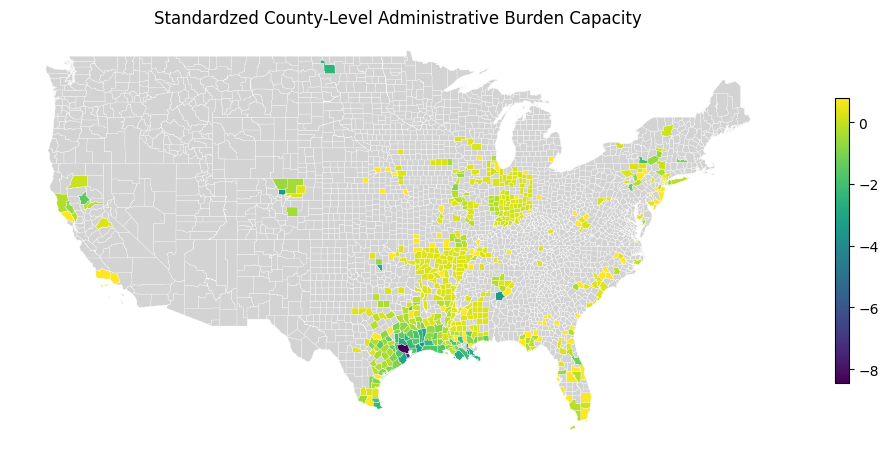

In [27]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np

county_shp = gpd.read_file("cb_2018_us_county_500k.zip")
state_shp = gpd.read_file("cb_2018_us_state_500k.zip")
county_shp = county_shp.merge(state_shp[['STATEFP', 'STUSPS']], how = 'left', on = 'STATEFP')
county_shp["county_name"] = county_shp["NAME"].str.lower().str.strip()
county_shp["state_abbr"] = county_shp["STUSPS"]

print(county_shp.columns)
print(state_shp.columns)

# df = pd.read_csv("all_state_local_fund_latent_var_4_v2.csv")

df["state_level"] = df["Grantee"].str.fullmatch(r"[A-Z]{2}").astype(int)

local_df = df[df["state_level"] == 0].copy()

local_df[["county_raw","state_abbr"]] = local_df["Grantee"].str.rsplit(", ", n=1, expand=True)

local_df["county_name"] = (
    local_df["county_raw"]
    .str.replace("County","",regex=False)
    .str.replace("Parish","",regex=False)
    .str.strip()
    .str.lower()
)
'''
local_df["AdminBurdenCapacity"] = local_df[
    ["z_rev_programs_per_staff","z_rev_disasters_per_staff"]
].mean(axis=1)

local_df["RecoveryTimeliness"] = local_df[
    ["z_rev_Duration_of_completion",
     "z_rev_Average_Duration_Program_Completion"]
].mean(axis=1)

local_df["RecoveryPerformance"] = local_df[
    ["z_Ratio_disbursed_to_obligated",
     "z_Ratio_expended_to_disbursed",
     "z_Ratio_obligated_funds_fully_expended",
     "z_Ratio_Program_Completed"]
].mean(axis=1)
'''

contiguous_state_list = ["AL", "AZ", "AR", "CA", "CO", "CT", "DE", "FL", "GA", "ID", "IL", "IN", 
                         "IA", "KS", "KY", "LA", "ME", "MD", "MA", "MI", "MN", "MS", "MO", "MT", 
                         "NE", "NV", "NH", "NJ", "NM", "NY", "NC", "ND", "OH", "OK", "OR", "PA",
                         "RI", "SC", "SD", "TN", "TX", "UT", "VT", "VA", "WA", "WV", "WI", "WY"]

gdf = county_shp.loc[county_shp['state_abbr'].isin(contiguous_state_list)].merge(
    local_df,
    on=["county_name","state_abbr"],
    how="left"
)

print("Matched counties:", gdf["AdminBurdenCapacity_proxy"].notna().sum())

fig, ax = plt.subplots(figsize=(10, 6))  # set figure size (width, height in inches)

gdf.plot(
    column="AdminBurdenCapacity_proxy",
    cmap="viridis",
    edgecolor="white",
    linewidth=0.2,
    legend=True,
    ax=ax,
    missing_kwds={"color": "lightgrey"},
    legend_kwds={"shrink": 0.5}
)

plt.title("Standardzed County-Level Administrative Burden Capacity")
plt.axis("off")

plt.tight_layout()
plt.savefig("county_map_burden_capacity.png",dpi=300)
plt.show()

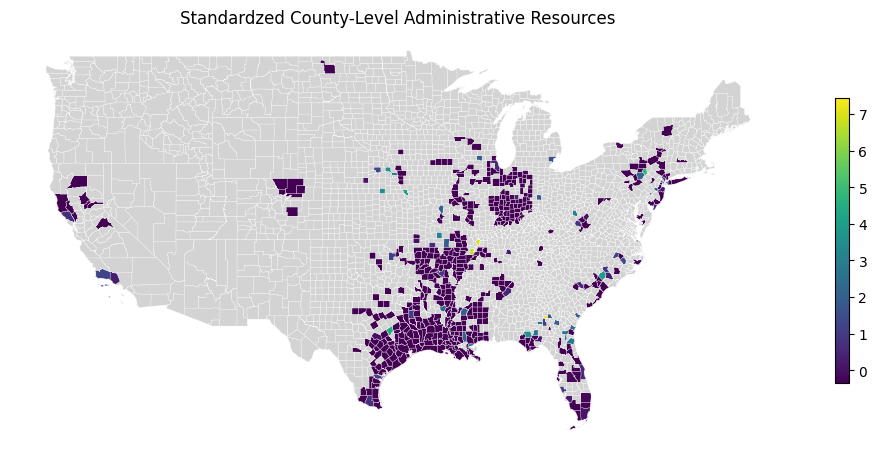

In [28]:
fig, ax = plt.subplots(figsize=(10, 6))  # set figure size (width, height in inches)

gdf.plot(
    column="AdminResources_proxy",
    cmap="viridis",
    edgecolor="white",
    linewidth=0.2,
    legend=True,
    ax=ax,
    missing_kwds={"color": "lightgrey"},
    legend_kwds={"shrink": 0.5}
)

plt.title("Standardzed County-Level Administrative Resources")
plt.axis("off")

plt.tight_layout()
plt.savefig("county_map_administrative_resources.png",dpi=300)
plt.show()

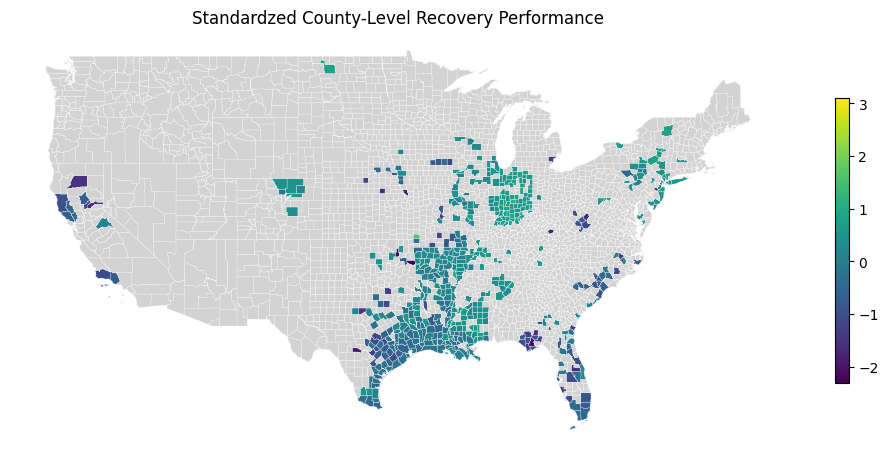

In [29]:
fig, ax = plt.subplots(figsize=(10, 6))  # set figure size (width, height in inches)

gdf.plot(
    column="RecoveryPerformance_proxy",
    cmap="viridis",
    edgecolor="white",
    linewidth=0.2,
    legend=True,
    ax=ax,
    missing_kwds={"color": "lightgrey"},
    legend_kwds={"shrink": 0.5}
)

plt.title("Standardzed County-Level Recovery Performance")
plt.axis("off")

plt.tight_layout()
plt.savefig("county_map_recovery_performance.png",dpi=300)
plt.show()

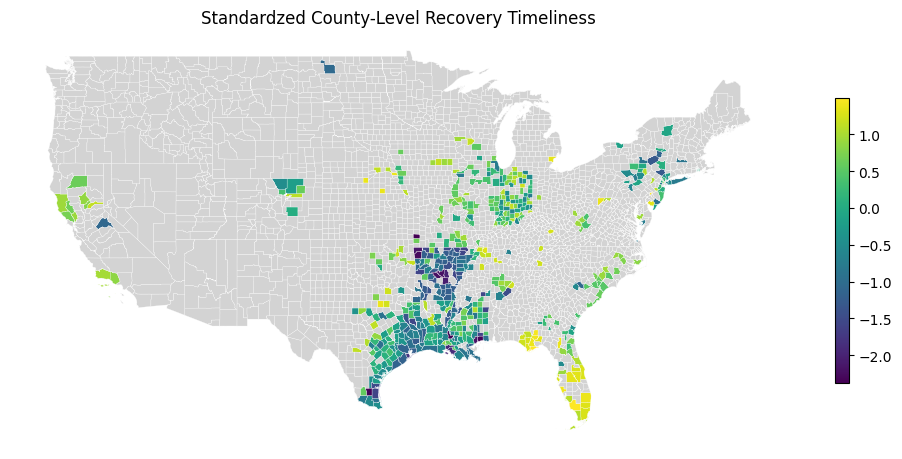

In [30]:
fig, ax = plt.subplots(figsize=(10, 6))  # set figure size (width, height in inches)

gdf.plot(
    column="RecoveryTimeliness_proxy",
    cmap="viridis",
    edgecolor="white",
    linewidth=0.2,
    legend=True,
    ax=ax,
    missing_kwds={"color": "lightgrey"},
    legend_kwds={"shrink": 0.5}
)

plt.title("Standardzed County-Level Recovery Timeliness")
plt.axis("off")

plt.tight_layout()
plt.savefig("county_map_recovery_timeliness.png",dpi=300)
plt.show()

#### Quadrant Policy Map

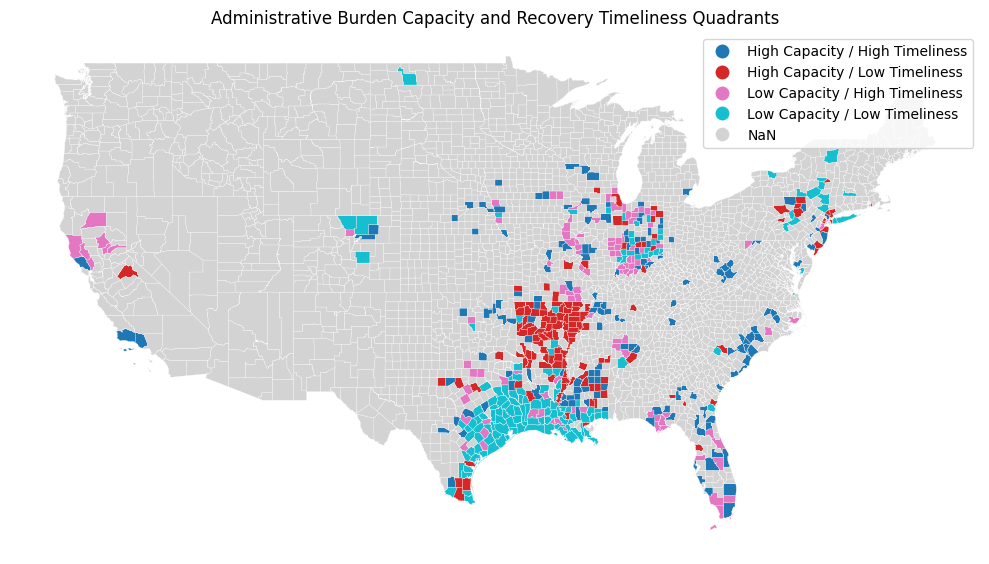

In [31]:
cap_med = gdf["AdminBurdenCapacity_proxy"].median()
tim_med = gdf["RecoveryTimeliness_proxy"].median()

def classify(row):

    cap=row["AdminBurdenCapacity_proxy"]
    tim=row["RecoveryTimeliness_proxy"]

    if pd.isna(cap) or pd.isna(tim):
        return None

    if cap>=cap_med and tim>=tim_med:
        return "High Capacity / High Timeliness"

    if cap>=cap_med and tim<tim_med:
        return "High Capacity / Low Timeliness"

    if cap<cap_med and tim>=tim_med:
        return "Low Capacity / High Timeliness"

    return "Low Capacity / Low Timeliness"


gdf["policy_group"]=gdf.apply(classify,axis=1)

fig,ax=plt.subplots(1,1,figsize=(10,6))

gdf.plot(
    column="policy_group",
    categorical=True,
    legend=True,
    edgecolor="white",
    linewidth=0.2,
    missing_kwds={"color":"lightgrey"},
    ax=ax
)

ax.set_title(
"Administrative Burden Capacity and Recovery Timeliness Quadrants"
)

ax.axis("off")

plt.tight_layout()
plt.savefig("policy_quadrant_map_burden_capacity_recovery_timeliness.png",dpi=300)
plt.show()

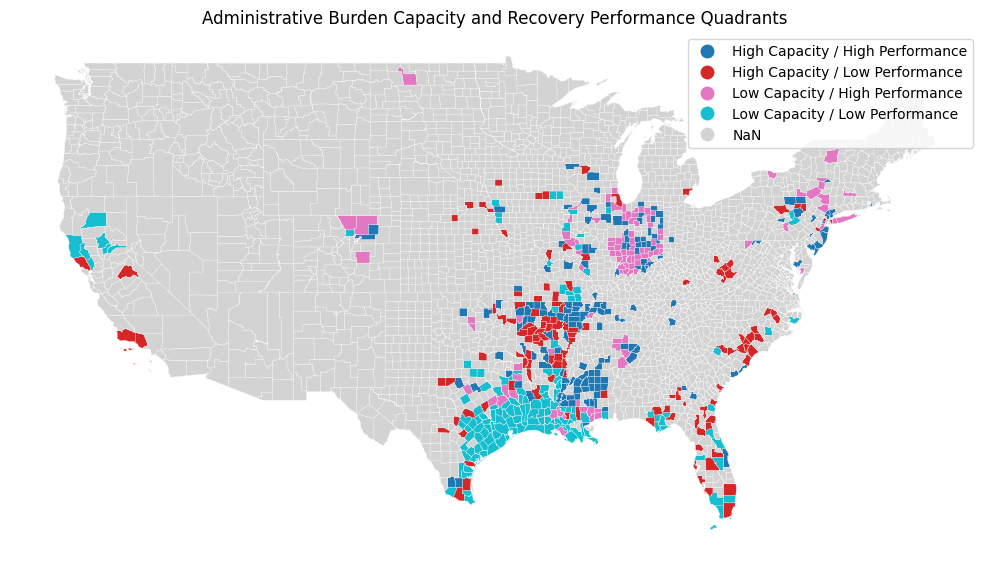

In [32]:
cap_med = gdf["AdminBurdenCapacity_proxy"].median()
tim_med = gdf["RecoveryPerformance_proxy"].median()

def classify(row):

    cap=row["AdminBurdenCapacity_proxy"]
    tim=row["RecoveryPerformance_proxy"]

    if pd.isna(cap) or pd.isna(tim):
        return None

    if cap>=cap_med and tim>=tim_med:
        return "High Capacity / High Performance"

    if cap>=cap_med and tim<tim_med:
        return "High Capacity / Low Performance"

    if cap<cap_med and tim>=tim_med:
        return "Low Capacity / High Performance"

    return "Low Capacity / Low Performance"


gdf["policy_group"]=gdf.apply(classify,axis=1)

fig,ax=plt.subplots(1,1,figsize=(10,7))

gdf.plot(
    column="policy_group",
    categorical=True,
    legend=True,
    edgecolor="white",
    linewidth=0.2,
    missing_kwds={"color":"lightgrey"},
    ax=ax
)

ax.set_title(
"Administrative Burden Capacity and Recovery Performance Quadrants"
)

ax.axis("off")

plt.tight_layout()
plt.savefig("policy_quadrant_map_burden_capacity_recovery_performance.png",dpi=300)
plt.show()

#### Capacity Gap

Matched local counties: 543


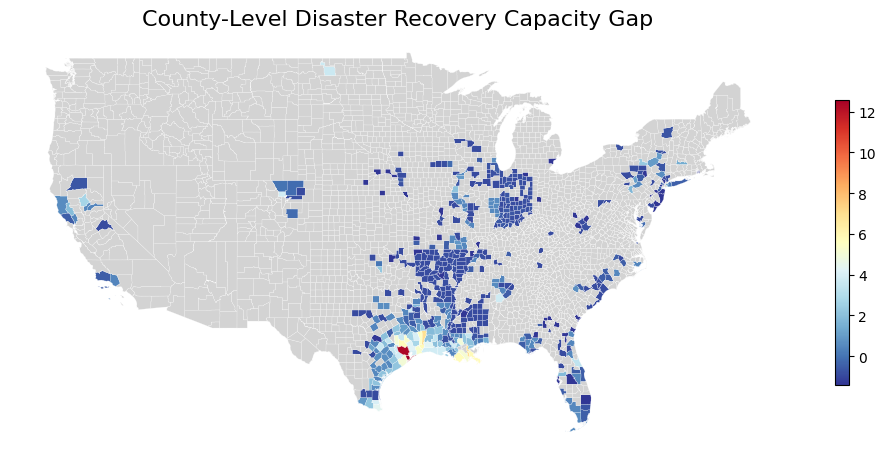

In [33]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler

# =========================================================
# 1. Load files
# =========================================================
county_shp = gpd.read_file("cb_2018_us_county_500k.zip")
state_shp = gpd.read_file("cb_2018_us_state_500k.zip")
df = pd.read_csv("all_state_local_fund_latent_var_4_v2.csv")

# =========================================================
# 2. Identify state vs local governments
# =========================================================
df["state_level"] = df["Grantee"].astype(str).str.fullmatch(r"[A-Z]{2}").astype(int)

# =========================================================
# 3. Recreate SEM-related variables if needed
# =========================================================
eps = 1e-6

df["programs_per_staff"] = df["Num_Program"] / (df["avg_employment"] + eps)
df["disasters_per_staff"] = df["Num_Disaster"] / (df["avg_employment"] + eps)

df["rev_programs_per_staff"] = -df["programs_per_staff"]
df["rev_disasters_per_staff"] = -df["disasters_per_staff"]

# standardize needed variables
vars_to_scale = [
    "Num_Disaster",
    "rev_programs_per_staff",
    "rev_disasters_per_staff"
]

scaler = StandardScaler()
zvals = scaler.fit_transform(df[vars_to_scale].fillna(df[vars_to_scale].median()))
zdf = pd.DataFrame(zvals, columns=[f"z_{c}" for c in vars_to_scale], index=df.index)
df = pd.concat([df, zdf], axis=1)

# =========================================================
# 4. Build capacity and exposure proxies
# =========================================================
df["AdminBurdenCapacity"] = df[
    ["z_rev_programs_per_staff", "z_rev_disasters_per_staff"]
].mean(axis=1)

df["DisasterExposure"] = df["z_Num_Disaster"]

# Capacity gap:
# high = high exposure and weak capacity
df["CapacityGap"] = df["DisasterExposure"] - df["AdminBurdenCapacity"]

# =========================================================
# 5. COUNTY-LEVEL MAP
# =========================================================
local_df = df[df["state_level"] == 0].copy()

# Parse grantee name like "Orange County, FL"
local_df[["county_raw", "state_abbr"]] = local_df["Grantee"].str.rsplit(", ", n=1, expand=True)

local_df["county_name"] = (
    local_df["county_raw"]
    .str.replace("County", "", regex=False)
    .str.replace("Parish", "", regex=False)
    .str.strip()
    .str.lower()
)

# prepare county shapefile keys
# county_shp["county_name"] = county_shp["NAME"].str.strip().str.lower()
# county_shp["state_abbr"] = county_shp["STUSPS"].str.strip()
county_shp = county_shp.merge(state_shp[['STATEFP', 'STUSPS']], how = 'left', on = 'STATEFP')
county_shp["county_name"] = county_shp["NAME"].str.lower().str.strip()
county_shp["state_abbr"] = county_shp["STUSPS"]

county_gdf = county_shp.loc[county_shp['state_abbr'].isin(contiguous_state_list)].merge(
    local_df,
    on=["county_name", "state_abbr"],
    how="left"
)

print("Matched local counties:", county_gdf["CapacityGap"].notna().sum())

# =========================================================
# 6. COUNTY CAPACITY-GAP MAP
# =========================================================
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

county_gdf.plot(
    column="CapacityGap",
    cmap="RdYlBu_r",   # red = higher gap, blue = lower gap
    linewidth=0.15,
    edgecolor="white",
    legend=True,
    missing_kwds={"color": "lightgrey", "label": "No data"},
    ax=ax,
    legend_kwds={"shrink": 0.5}
)

ax.set_title("County-Level Disaster Recovery Capacity Gap", fontsize=16)
ax.axis("off")

plt.tight_layout()
plt.savefig("county_capacity_gap_map.png", dpi=300, bbox_inches="tight")
plt.show()

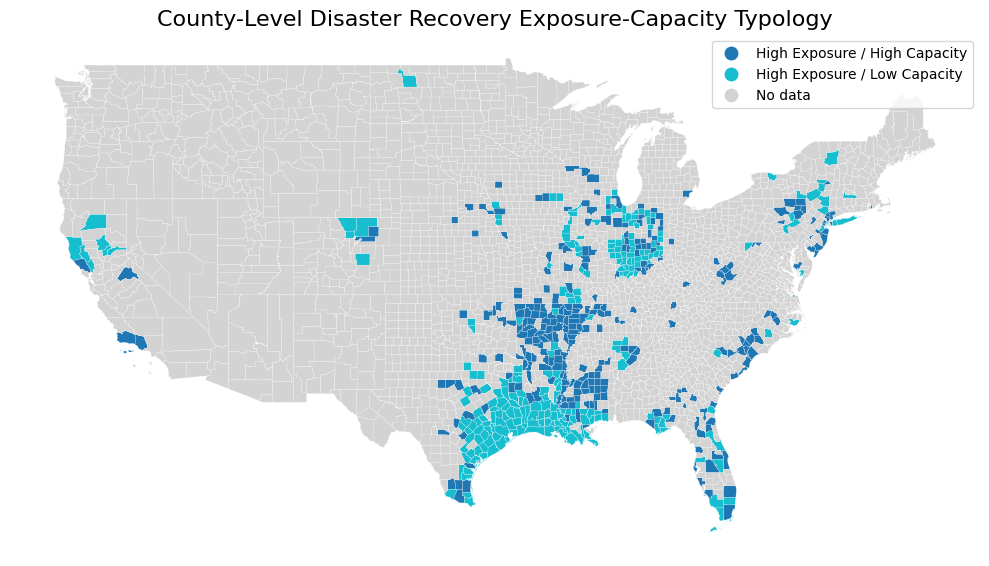

In [34]:
# =========================================================
# 7. COUNTY PRIORITY QUADRANT MAP
#    Exposure x Capacity
# =========================================================
exp_med = local_df["DisasterExposure"].median()
cap_med = local_df["AdminBurdenCapacity"].median()

def classify_gap(row):
    exp_ = row["DisasterExposure"]
    cap_ = row["AdminBurdenCapacity"]

    if pd.isna(exp_) or pd.isna(cap_):
        return None
    elif exp_ >= exp_med and cap_ < cap_med:
        return "High Exposure / Low Capacity"
    elif exp_ >= exp_med and cap_ >= cap_med:
        return "High Exposure / High Capacity"
    elif exp_ < exp_med and cap_ < cap_med:
        return "Low Exposure / Low Capacity"
    else:
        return "Low Exposure / High Capacity"

local_df["gap_group"] = local_df.apply(classify_gap, axis=1)

county_gdf_quad = county_shp.loc[county_shp['state_abbr'].isin(contiguous_state_list)].merge(
    local_df[["county_name", "state_abbr", "gap_group"]],
    on=["county_name", "state_abbr"],
    how="left"
)

fig, ax = plt.subplots(1, 1, figsize=(10, 6))

county_gdf_quad.plot(
    column="gap_group",
    categorical=True,
    legend=True,
    linewidth=0.15,
    edgecolor="white",
    missing_kwds={"color": "lightgrey", "label": "No data"},
    ax=ax
)

ax.set_title("County-Level Disaster Recovery Exposure-Capacity Typology", fontsize=16)
ax.axis("off")

plt.tight_layout()
plt.savefig("county_capacity_gap_quadrant_map.png", dpi=300, bbox_inches="tight")
plt.show()

Matched states: 30


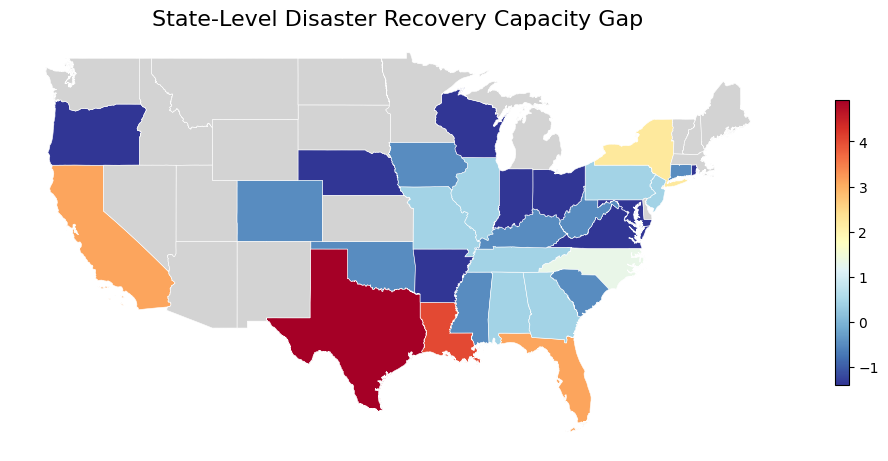


Top 20 county capacity gaps:
               Grantee  DisasterExposure  AdminBurdenCapacity  CapacityGap
  Galveston County, TX          5.715918            -6.870628    12.586546
     Harris County, TX          3.909243            -8.435342    12.344586
     Newton County, TX          3.909243            -3.038870     6.948113
  Jefferson Parish, LA          3.005906            -3.914270     6.920176
     Orange County, TX          2.102569            -3.673158     5.775727
Plaquemines Parish, LA          3.005906            -2.760541     5.766447
 Montgomery County, TX          3.005906            -2.741932     5.747839
 Terrebonne Parish, LA          3.005906            -2.704715     5.710621
     Jasper County, TX          3.005906            -2.425588     5.431494
San Jacinto County, TX          3.005906            -2.369762     5.375668
  Jefferson County, TX          2.102569            -3.170728     5.273296
  Lafourche Parish, LA          3.005906            -2.109243     5.11

In [35]:
# =========================================================
# 8. STATE-LEVEL MAP
# =========================================================
state_df = df[df["state_level"] == 1].copy()
state_df["state_abbr"] = state_df["Grantee"].str.strip()

state_shp["state_abbr"] = state_shp["STUSPS"].str.strip()

state_gdf = state_shp.loc[state_shp['state_abbr'].isin(contiguous_state_list)].merge(
    state_df,
    on="state_abbr",
    how="left"
)

print("Matched states:", state_gdf["CapacityGap"].notna().sum())

fig, ax = plt.subplots(1, 1, figsize=(10, 6))

state_gdf.plot(
    column="CapacityGap",
    cmap="RdYlBu_r",
    linewidth=0.4,
    edgecolor="white",
    legend=True,
    missing_kwds={"color": "lightgrey", "label": "No data"},
    ax=ax,
    legend_kwds={"shrink": 0.5}
)

ax.set_title("State-Level Disaster Recovery Capacity Gap", fontsize=16)
ax.axis("off")

plt.tight_layout()
plt.savefig("state_capacity_gap_map.png", dpi=300, bbox_inches="tight")
plt.show()

# =========================================================
# 9. Top priority lists
# =========================================================
top_county_gap = (
    local_df[["Grantee", "DisasterExposure", "AdminBurdenCapacity", "CapacityGap"]]
    .sort_values("CapacityGap", ascending=False)
    .head(20)
)

top_state_gap = (
    state_df[["Grantee", "DisasterExposure", "AdminBurdenCapacity", "CapacityGap"]]
    .sort_values("CapacityGap", ascending=False)
    .head(20)
)

top_county_gap.to_csv("top20_county_capacity_gap.csv", index=False)
top_state_gap.to_csv("top20_state_capacity_gap.csv", index=False)

print("\nTop 20 county capacity gaps:")
print(top_county_gap.to_string(index=False))

print("\nTop 20 state capacity gaps:")
print(top_state_gap.to_string(index=False))

##### Risk Map

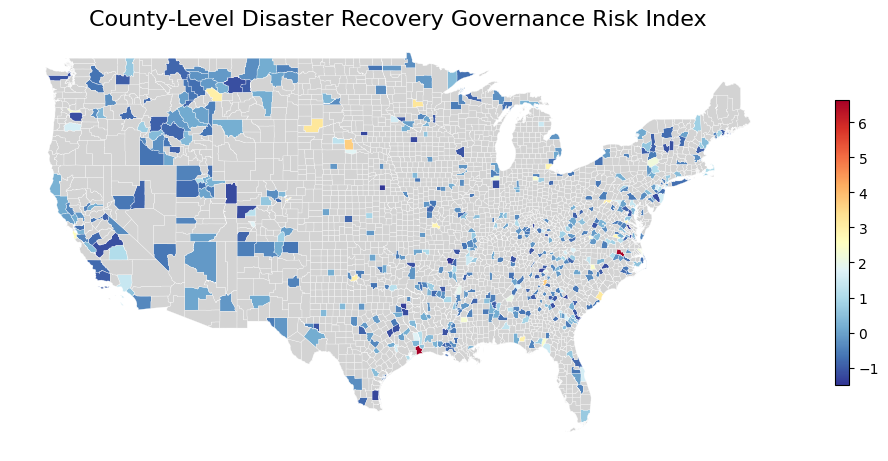

                    Grantee  DisasterExposure  AdminBurdenCapacity  \
201       Harris County, TX          3.909243            -8.435342   
173    Galveston County, TX          5.715918            -6.870628   
249    Jefferson Parish, LA          3.005906            -3.914270   
374       Newton County, TX          3.909243            -3.038870   
506   Terrebonne Parish, LA          3.005906            -2.704715   
247    Jefferson County, TX          2.102569            -3.170728   
242       Jasper County, TX          3.005906            -2.425588   
414  Plaquemines Parish, LA          3.005906            -2.760541   
191       Grimes County, TX          3.005906            -2.090634   
390       Orange County, TX          2.102569            -3.673158   
453  San Jacinto County, TX          3.005906            -2.369762   
64       Cameron County, TX          2.102569            -2.258910   
271    Lafourche Parish, LA          3.005906            -2.109243   
350   Montgomery Cou

In [36]:
# ======================================================
# POLICY TARGETING INDEX
# ======================================================

# standardize needed variables
vars_to_scale = [
    "SPL_THEME1",
    "SPL_THEME2",
    "SPL_THEME3",
    "SPL_THEME4"
]

scaler = StandardScaler()
zvals = scaler.fit_transform(local_df[vars_to_scale].fillna(local_df[vars_to_scale].median()))
zdf = pd.DataFrame(zvals, columns=[f"z_{c}" for c in vars_to_scale], index=local_df.index)
local_df = pd.concat([local_df, zdf], axis=1)

# build vulnerability index
local_df["VulnerabilityIndex"] = local_df[
    ["z_SPL_THEME1", "z_SPL_THEME2", "z_SPL_THEME3", "z_SPL_THEME4"]
].mean(axis=1)

# recovery governance risk
local_df["RecoveryRiskIndex"] = (
      local_df["DisasterExposure"]
    + local_df["VulnerabilityIndex"]
    - local_df["AdminBurdenCapacity"]
)

# normalize again for interpretation
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

local_df["RecoveryRiskIndex_z"] = scaler.fit_transform(
    local_df[["RecoveryRiskIndex"]]
)

# identify the top 20
risk_rank = (
    local_df[["Grantee",
        "DisasterExposure",
        "AdminBurdenCapacity",
        "VulnerabilityIndex",
        "RecoveryRiskIndex_z"]]
    .sort_values("RecoveryRiskIndex_z", ascending=False)
)

top20 = risk_rank.head(20)

top20.to_csv("top20_county_recovery_governance_risk.csv", index=False)

# prepare county shapefile keys
# county_shp["county_name"] = county_shp["NAME"].str.strip().str.lower()
# county_shp["state_abbr"] = county_shp["STUSPS"].str.strip()

# Risk map
county_gdf = county_shp.loc[county_shp['state_abbr'].isin(contiguous_state_list)].merge(
    local_df,
    on=["county_name","state_abbr"],
    how="left"
)

county_gdf["RecoveryRiskIndex_z"] = local_df["RecoveryRiskIndex_z"]

fig, ax = plt.subplots(1, 1, figsize=(10, 6))

county_gdf.plot(
    column="RecoveryRiskIndex_z",
    cmap="RdYlBu_r",
    linewidth=0.2,
    edgecolor="white",
    legend=True,
    missing_kwds={"color":"lightgrey"},
    ax=ax,
    legend_kwds={"shrink": 0.5}
)

ax.set_title(
"County-Level Disaster Recovery Governance Risk Index",
fontsize=16
)
ax.axis("off")

plt.tight_layout()
plt.savefig("county_recovery_governance_risk_map.png", dpi=300)
plt.show()

print(top20)

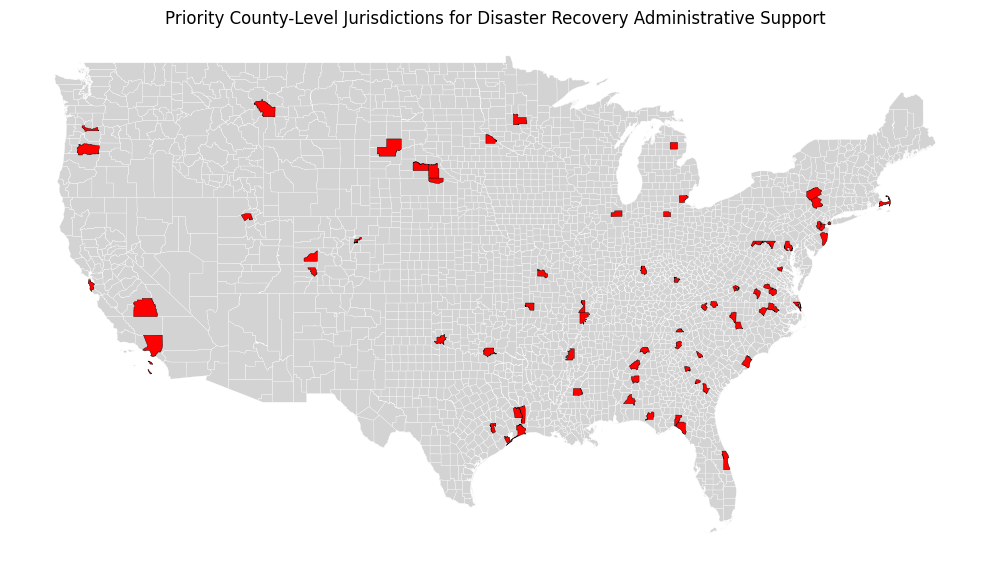

In [37]:
# policy priority counties
county_gdf["priority"] = county_gdf["RecoveryRiskIndex_z"] > 1

fig, ax = plt.subplots(1, 1, figsize=(10,6))

county_gdf.plot(
    color="lightgrey",
    edgecolor="white",
    linewidth=0.2,
    ax=ax
)

county_gdf[county_gdf["priority"]].plot(
    color="red",
    edgecolor="black",
    linewidth=0.3,
    ax=ax,
    legend_kwds={"shrink": 0.5}
)

ax.set_title(
"Priority County-Level Jurisdictions for Disaster Recovery Administrative Support"
)

ax.axis("off")
plt.tight_layout()
plt.savefig("county_recovery_governance_risk_priority_map.png", dpi=300)
plt.show()

#### Implementation Gap

Matched local counties: 543


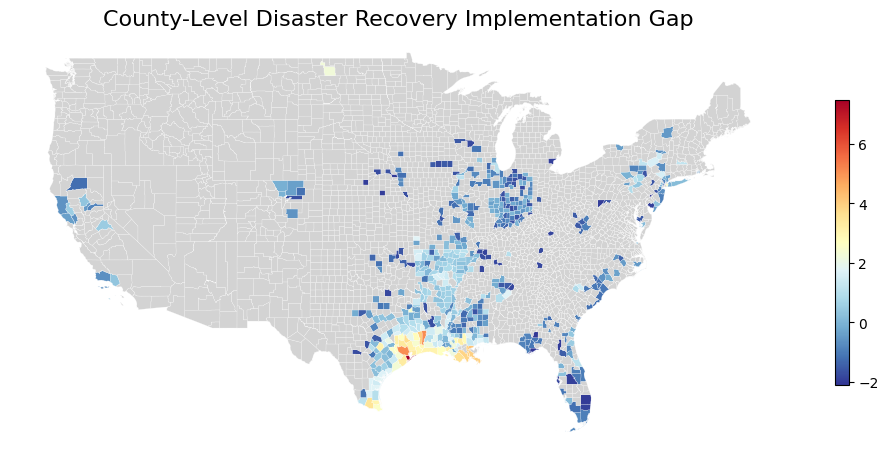

In [38]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler

# =========================================================
# 1. Load files
# =========================================================
county_shp = gpd.read_file("cb_2018_us_county_500k.zip")
state_shp = gpd.read_file("cb_2018_us_state_500k.zip")
df = pd.read_csv("all_state_local_fund_latent_var_4_v2.csv")

# =========================================================
# 2. Identify state vs local governments
# =========================================================
df["state_level"] = df["Grantee"].astype(str).str.fullmatch(r"[A-Z]{2}").astype(int)

# =========================================================
# 3. Recreate SEM-related variables if needed
# =========================================================
df["rev_Duration_of_completion"] = -df["Duration_of_completion"]
df["rev_Average_Duration_Program_Completion"] = -df["Average_Duration_Program_Completion"]

# standardize needed variables
vars_to_scale = [
    "Num_Disaster",
    "rev_Duration_of_completion",
    "rev_Average_Duration_Program_Completion"
]

scaler = StandardScaler()
zvals = scaler.fit_transform(df[vars_to_scale].fillna(df[vars_to_scale].median()))
zdf = pd.DataFrame(zvals, columns=[f"z_{c}" for c in vars_to_scale], index=df.index)
df = pd.concat([df, zdf], axis=1)

# =========================================================
# 4. Build capacity and exposure proxies
# =========================================================

df["RecoveryTimeliness"] = df[[
    "z_rev_Duration_of_completion",
    "z_rev_Average_Duration_Program_Completion"
]].mean(axis=1)

df["DisasterExposure"] = df["z_Num_Disaster"]

# Capacity gap:
# high = high exposure and weak capacity
df["ImplementationGap"] = df["DisasterExposure"] - df["RecoveryTimeliness"]

# =========================================================
# 5. COUNTY-LEVEL MAP
# =========================================================
local_df = df[df["state_level"] == 0].copy()

# Parse grantee name like "Orange County, FL"
local_df[["county_raw", "state_abbr"]] = local_df["Grantee"].str.rsplit(", ", n=1, expand=True)

local_df["county_name"] = (
    local_df["county_raw"]
    .str.replace("County", "", regex=False)
    .str.replace("Parish", "", regex=False)
    .str.strip()
    .str.lower()
)

# prepare county shapefile keys
# county_shp["county_name"] = county_shp["NAME"].str.strip().str.lower()
# county_shp["state_abbr"] = county_shp["STUSPS"].str.strip()
county_shp = county_shp.merge(state_shp[['STATEFP', 'STUSPS']], how = 'left', on = 'STATEFP')
county_shp["county_name"] = county_shp["NAME"].str.lower().str.strip()
county_shp["state_abbr"] = county_shp["STUSPS"]

county_gdf = county_shp.loc[county_shp['state_abbr'].isin(contiguous_state_list)].merge(
    local_df,
    on=["county_name", "state_abbr"],
    how="left"
)

print("Matched local counties:", county_gdf["ImplementationGap"].notna().sum())

# =========================================================
# 6. COUNTY CAPACITY-GAP MAP
# =========================================================
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

county_gdf.plot(
    column="ImplementationGap",
    cmap="RdYlBu_r",   # red = higher gap, blue = lower gap
    linewidth=0.15,
    edgecolor="white",
    legend=True,
    missing_kwds={"color": "lightgrey", "label": "No data"},
    ax=ax,
    legend_kwds={"shrink": 0.5}
)

ax.set_title("County-Level Disaster Recovery Implementation Gap", fontsize=16)
ax.axis("off")

plt.tight_layout()
plt.savefig("county_implementation_gap_map.png", dpi=300, bbox_inches="tight")
plt.show()

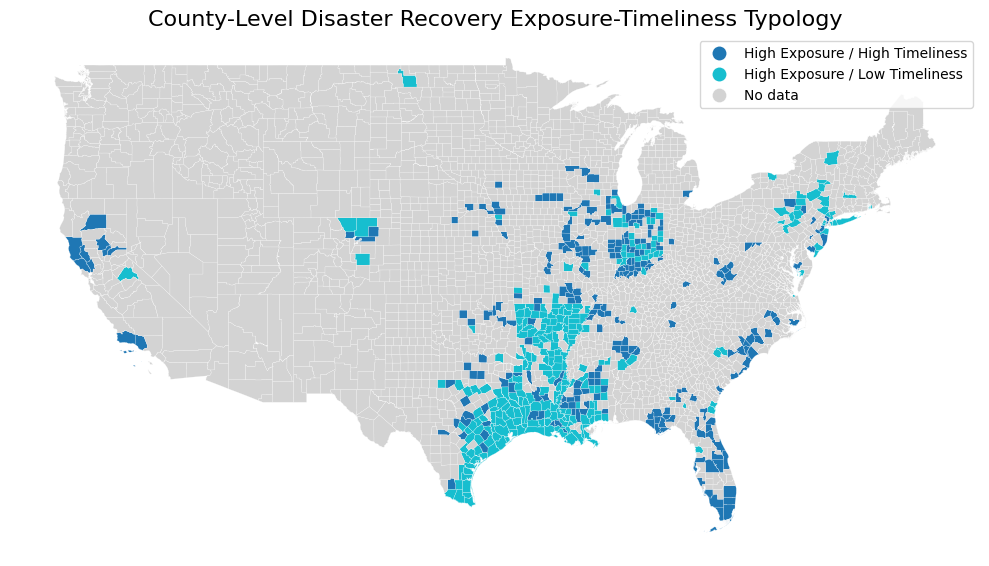

In [39]:
# =========================================================
# 7. COUNTY PRIORITY QUADRANT MAP
#    Exposure x Capacity
# =========================================================
exp_med = local_df["DisasterExposure"].median()
cap_med = local_df["RecoveryTimeliness"].median()

def classify_gap(row):
    exp_ = row["DisasterExposure"]
    cap_ = row["RecoveryTimeliness"]

    if pd.isna(exp_) or pd.isna(cap_):
        return None
    elif exp_ >= exp_med and cap_ < cap_med:
        return "High Exposure / Low Timeliness"
    elif exp_ >= exp_med and cap_ >= cap_med:
        return "High Exposure / High Timeliness"
    elif exp_ < exp_med and cap_ < cap_med:
        return "Low Exposure / Low Timeliness"
    else:
        return "Low Exposure / High Timeliness"

local_df["gap_group"] = local_df.apply(classify_gap, axis=1)

county_gdf_quad = county_shp.loc[county_shp['state_abbr'].isin(contiguous_state_list)].merge(
    local_df[["county_name", "state_abbr", "gap_group"]],
    on=["county_name", "state_abbr"],
    how="left"
)

fig, ax = plt.subplots(1, 1, figsize=(10, 6))

county_gdf_quad.plot(
    column="gap_group",
    categorical=True,
    legend=True,
    linewidth=0.15,
    edgecolor="white",
    missing_kwds={"color": "lightgrey", "label": "No data"},
    ax=ax
)

ax.set_title("County-Level Disaster Recovery Exposure-Timeliness Typology", fontsize=16)
ax.axis("off")

plt.tight_layout()
plt.savefig("county_implementation_gap_quadrant_map.png", dpi=300, bbox_inches="tight")
plt.show()

Matched states: 30


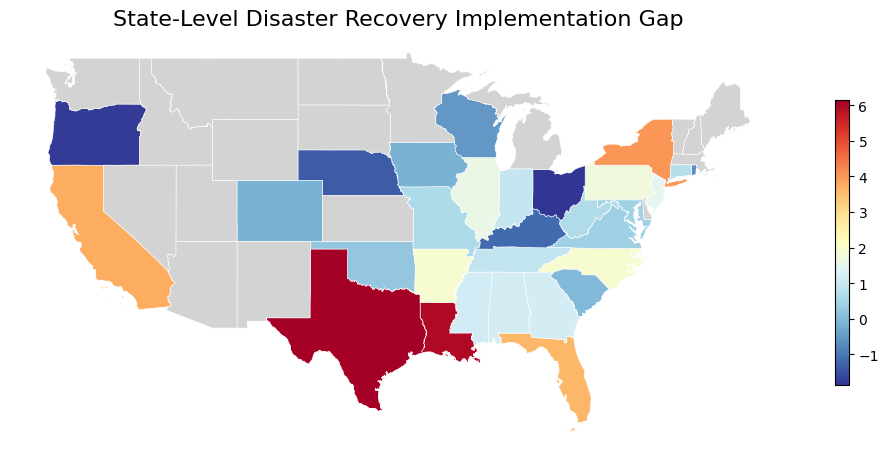


Top 20 county implementation gaps:
               Grantee  DisasterExposure  RecoveryTimeliness  ImplementationGap
  Galveston County, TX          5.715918           -1.769021           7.484939
     Newton County, TX          3.909243           -1.209841           5.119084
     Harris County, TX          3.909243           -1.141589           5.050833
    Orleans Parish, LA          3.005906           -1.202262           4.208168
     Jasper County, TX          3.005906           -0.982148           3.988054
Plaquemines Parish, LA          3.005906           -0.948528           3.954434
  Jefferson Parish, LA          3.005906           -0.911520           3.917426
  Lafourche Parish, LA          3.005906           -0.866082           3.871988
San Jacinto County, TX          3.005906           -0.682626           3.688532
 Terrebonne Parish, LA          3.005906           -0.618258           3.624164
    Hidalgo County, TX          3.005906           -0.534432           3.540338
 Mon

In [40]:
# =========================================================
# 8. STATE-LEVEL MAP
# =========================================================
state_df = df[df["state_level"] == 1].copy()
state_df["state_abbr"] = state_df["Grantee"].str.strip()

state_shp["state_abbr"] = state_shp["STUSPS"].str.strip()

state_gdf = state_shp.loc[state_shp['state_abbr'].isin(contiguous_state_list)].merge(
    state_df,
    on="state_abbr",
    how="left"
)

print("Matched states:", state_gdf["ImplementationGap"].notna().sum())

fig, ax = plt.subplots(1, 1, figsize=(10, 6))

state_gdf.plot(
    column="ImplementationGap",
    cmap="RdYlBu_r",
    linewidth=0.4,
    edgecolor="white",
    legend=True,
    missing_kwds={"color": "lightgrey", "label": "No data"},
    ax=ax,
    legend_kwds={"shrink": 0.5}
)

ax.set_title("State-Level Disaster Recovery Implementation Gap", fontsize=16)
ax.axis("off")

plt.tight_layout()
plt.savefig("state_implementation_gap_map.png", dpi=300, bbox_inches="tight")
plt.show()

# =========================================================
# 9. Top priority lists
# =========================================================
top_county_gap = (
    local_df[["Grantee", "DisasterExposure", "RecoveryTimeliness", "ImplementationGap"]]
    .sort_values("ImplementationGap", ascending=False)
    .head(20)
)

top_state_gap = (
    state_df[["Grantee", "DisasterExposure", "RecoveryTimeliness", "ImplementationGap"]]
    .sort_values("ImplementationGap", ascending=False)
    .head(20)
)

top_county_gap.to_csv("top20_county_implementation_gap.csv", index=False)
top_state_gap.to_csv("top20_state_implementation_gap.csv", index=False)

print("\nTop 20 county implementation gaps:")
print(top_county_gap.to_string(index=False))

print("\nTop 20 state implementation gaps:")
print(top_state_gap.to_string(index=False))

#### Performance Gap

Matched local counties: 543


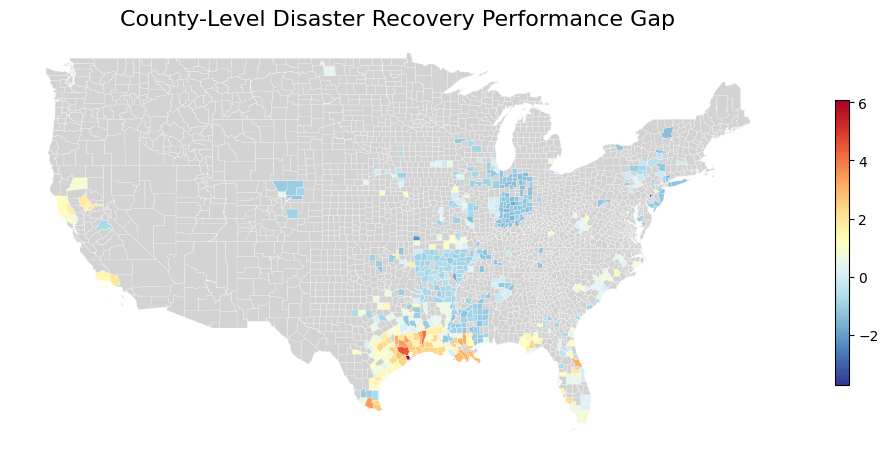

In [41]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler

# =========================================================
# 1. Load files
# =========================================================
county_shp = gpd.read_file("cb_2018_us_county_500k.zip")
state_shp = gpd.read_file("cb_2018_us_state_500k.zip")
df = pd.read_csv("all_state_local_fund_latent_var_4_v2.csv")

# =========================================================
# 2. Identify state vs local governments
# =========================================================
df["state_level"] = df["Grantee"].astype(str).str.fullmatch(r"[A-Z]{2}").astype(int)

# standardize needed variables
vars_to_scale = [
    "Num_Disaster",
    "Ratio_disbursed_to_obligated",
    "Ratio_expended_to_disbursed",
    "Ratio_obligated_funds_fully_expended",
    "Ratio_Program_Completed"
]

scaler = StandardScaler()
zvals = scaler.fit_transform(df[vars_to_scale].fillna(df[vars_to_scale].median()))
zdf = pd.DataFrame(zvals, columns=[f"z_{c}" for c in vars_to_scale], index=df.index)
df = pd.concat([df, zdf], axis=1)

# =========================================================
# 4. Build capacity and exposure proxies
# =========================================================

df["RecoveryPerformance"] = df[[
    "z_Ratio_disbursed_to_obligated",
    "z_Ratio_expended_to_disbursed",
    "z_Ratio_obligated_funds_fully_expended",
    "z_Ratio_Program_Completed"
]].mean(axis=1)

df["DisasterExposure"] = df["z_Num_Disaster"]

# Capacity gap:
# high = high exposure and weak capacity
df["PerformanceGap"] = df["DisasterExposure"] - df["RecoveryPerformance"]

# =========================================================
# 5. COUNTY-LEVEL MAP
# =========================================================
local_df = df[df["state_level"] == 0].copy()

# Parse grantee name like "Orange County, FL"
local_df[["county_raw", "state_abbr"]] = local_df["Grantee"].str.rsplit(", ", n=1, expand=True)

local_df["county_name"] = (
    local_df["county_raw"]
    .str.replace("County", "", regex=False)
    .str.replace("Parish", "", regex=False)
    .str.strip()
    .str.lower()
)

# prepare county shapefile keys
# county_shp["county_name"] = county_shp["NAME"].str.strip().str.lower()
# county_shp["state_abbr"] = county_shp["STUSPS"].str.strip()
county_shp = county_shp.merge(state_shp[['STATEFP', 'STUSPS']], how = 'left', on = 'STATEFP')
county_shp["county_name"] = county_shp["NAME"].str.lower().str.strip()
county_shp["state_abbr"] = county_shp["STUSPS"]

county_gdf = county_shp.loc[county_shp['state_abbr'].isin(contiguous_state_list)].merge(
    local_df,
    on=["county_name", "state_abbr"],
    how="left"
)

print("Matched local counties:", county_gdf["PerformanceGap"].notna().sum())

# =========================================================
# 6. COUNTY CAPACITY-GAP MAP
# =========================================================
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

county_gdf.plot(
    column="PerformanceGap",
    cmap="RdYlBu_r",   # red = higher gap, blue = lower gap
    linewidth=0.15,
    edgecolor="white",
    legend=True,
    missing_kwds={"color": "lightgrey", "label": "No data"},
    ax=ax,
    legend_kwds={"shrink": 0.5}
)

ax.set_title("County-Level Disaster Recovery Performance Gap", fontsize=16)
ax.axis("off")

plt.tight_layout()
plt.savefig("county_performance_gap_map.png", dpi=300, bbox_inches="tight")
plt.show()

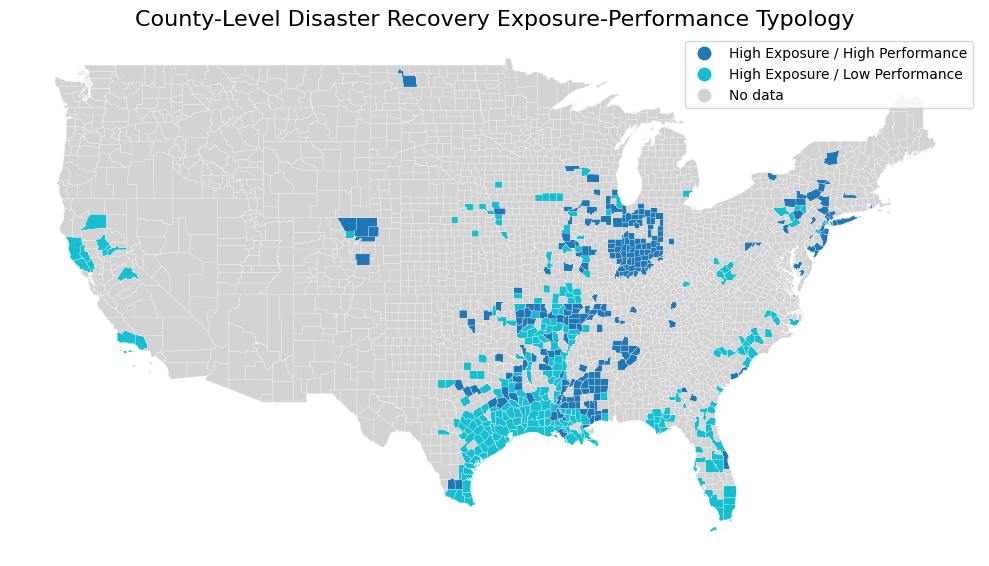

In [42]:
# =========================================================
# 7. COUNTY PRIORITY QUADRANT MAP
#    Exposure x Capacity
# =========================================================
exp_med = local_df["DisasterExposure"].median()
cap_med = local_df["RecoveryPerformance"].median()

def classify_gap(row):
    exp_ = row["DisasterExposure"]
    cap_ = row["RecoveryPerformance"]

    if pd.isna(exp_) or pd.isna(cap_):
        return None
    elif exp_ >= exp_med and cap_ < cap_med:
        return "High Exposure / Low Performance"
    elif exp_ >= exp_med and cap_ >= cap_med:
        return "High Exposure / High Performance"
    elif exp_ < exp_med and cap_ < cap_med:
        return "Low Exposure / Low Performance"
    else:
        return "Low Exposure / High Performance"

local_df["gap_group"] = local_df.apply(classify_gap, axis=1)

county_gdf_quad = county_shp.loc[county_shp['state_abbr'].isin(contiguous_state_list)].merge(
    local_df[["county_name", "state_abbr", "gap_group"]],
    on=["county_name", "state_abbr"],
    how="left"
)

fig, ax = plt.subplots(1, 1, figsize=(10, 6))

county_gdf_quad.plot(
    column="gap_group",
    categorical=True,
    legend=True,
    linewidth=0.15,
    edgecolor="white",
    missing_kwds={"color": "lightgrey", "label": "No data"},
    ax=ax
)

ax.set_title("County-Level Disaster Recovery Exposure-Performance Typology", fontsize=16)
ax.axis("off")

plt.tight_layout()
plt.savefig("county_performance_gap_quadrant_map.png", dpi=300, bbox_inches="tight")
plt.show()

Matched states: 30


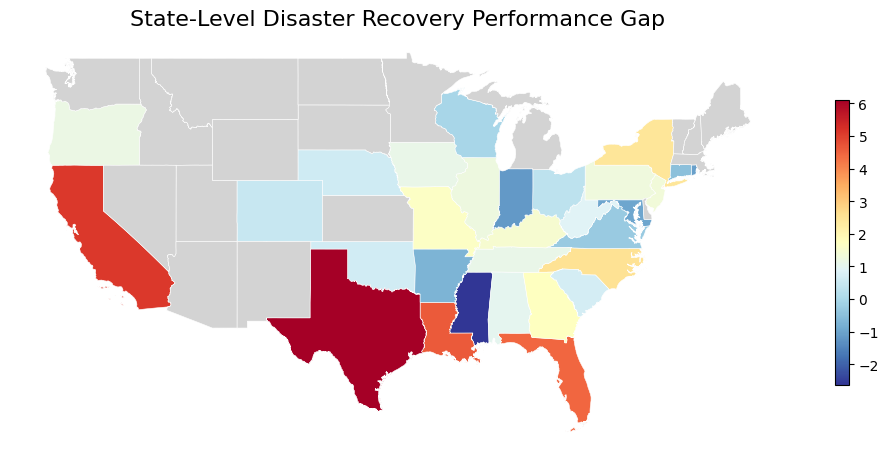


Top 20 county performance gaps:
               Grantee  DisasterExposure  RecoveryPerformance  PerformanceGap
  Galveston County, TX          5.715918            -0.370527        6.086445
     Harris County, TX          3.909243            -0.585061        4.494305
     Newton County, TX          3.909243            -0.217084        4.126327
    Hidalgo County, TX          3.005906            -0.423459        3.429365
 Montgomery County, TX          3.005906            -0.391979        3.397885
San Jacinto County, TX          3.005906            -0.321158        3.327064
     Grimes County, TX          3.005906            -0.161723        3.167629
 Tangipahoa Parish, LA          3.005906            -0.158934        3.164840
 Livingston Parish, LA          3.005906            -0.136223        3.142129
    Volusia County, FL          2.102569            -0.986191        3.088759
     Jasper County, TX          3.005906            -0.065797        3.071703
  Jefferson Parish, LA         

In [43]:
# =========================================================
# 8. STATE-LEVEL MAP
# =========================================================
state_df = df[df["state_level"] == 1].copy()
state_df["state_abbr"] = state_df["Grantee"].str.strip()

state_shp["state_abbr"] = state_shp["STUSPS"].str.strip()

state_gdf = state_shp.loc[state_shp['state_abbr'].isin(contiguous_state_list)].merge(
    state_df,
    on="state_abbr",
    how="left"
)

print("Matched states:", state_gdf["PerformanceGap"].notna().sum())

fig, ax = plt.subplots(1, 1, figsize=(10, 6))

state_gdf.plot(
    column="PerformanceGap",
    cmap="RdYlBu_r",
    linewidth=0.4,
    edgecolor="white",
    legend=True,
    missing_kwds={"color": "lightgrey", "label": "No data"},
    ax=ax,
    legend_kwds={"shrink": 0.5}
)

ax.set_title("State-Level Disaster Recovery Performance Gap", fontsize=16)
ax.axis("off")

plt.tight_layout()
plt.savefig("state_performance_gap_map.png", dpi=300, bbox_inches="tight")
plt.show()

# =========================================================
# 9. Top priority lists
# =========================================================
top_county_gap = (
    local_df[["Grantee", "DisasterExposure", "RecoveryPerformance", "PerformanceGap"]]
    .sort_values("PerformanceGap", ascending=False)
    .head(20)
)

top_state_gap = (
    state_df[["Grantee", "DisasterExposure", "RecoveryPerformance", "PerformanceGap"]]
    .sort_values("PerformanceGap", ascending=False)
    .head(20)
)

top_county_gap.to_csv("top20_county_performance_gap.csv", index=False)
top_state_gap.to_csv("top20_state_performance_gap.csv", index=False)

print("\nTop 20 county performance gaps:")
print(top_county_gap.to_string(index=False))

print("\nTop 20 state performance gaps:")
print(top_state_gap.to_string(index=False))